<a href="https://colab.research.google.com/github/Jholman22/ProcesamientoImagenes2025/blob/main/Clasificaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://medellin.unal.edu.co/eventos/panam2018/images/imagenes/organizan_2.png" width="40%">

# Procesamiento Digital de Imágenes

## Departamento de ingeniería eléctrica, electrónica y computación
## Sede Manizales

### Profesores Diego Pérez

###  ¿Qué es la clasificación de imágenes?

La clasificación de imágenes es una tarea de visión por computadora cuyo objetivo es asignar una etiqueta o clase a una imagen completa. El modelo aprende patrones visuales a partir de los datos de entrenamiento.

#### Ejemplos comunes:
- Clasificar entre "perro" o "gato"
- Distinguir tipos de células en medicina
- Identificar si un producto está dañado

In [ ]:
#Packages:
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation
from tensorflow.keras.datasets import cifar10

#Packages from optimizing the model:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import optimizers

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Load the data:
(x_train, y_train), (x_test, y_test)=cifar10.load_data()

In [ ]:
x_train.shape #I have 50000 images of train where every one have resolution of 32x32 and is in RGB space color

(50000, 32, 32, 3)

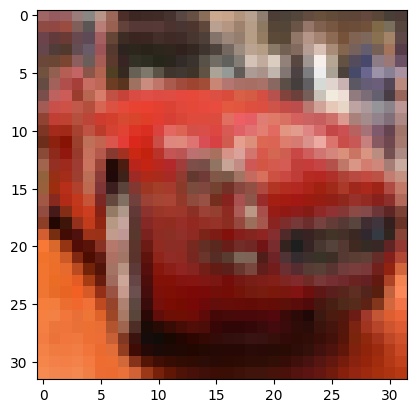

In [ ]:
#Painting a image:
plt.imshow(x_train[5])

#Red neuronal:

In [ ]:
x_train=x_train.astype("float32")
x_test=x_test.astype("float32")/255

In [ ]:
len(np.unique(y_train)) #I have only 10 classes

10

In [ ]:
#Binarizing the labels:
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

In [ ]:
y_train[0]

array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])

In [ ]:
#Normalizing the data lessing the mean and the standard desviation to every data (This stayes the data between 0 and 1):
mean=np.mean(x_train)
sd=np.std(x_train)
#I add a very samll number in the denominator for if the sd=0
x_train=(x_train-mean)/(sd+1e-7)
x_test=(x_test-mean)/(sd+1e-7) #IU normalize with the mean and the sd of the train set because the idea is that the network doesn´t know these parameters of the test set

In [ ]:
#Train_test_val_split:
(x_train,x_valid)=x_train[5000:],x_train[:5000]
(y_train,y_valid)=y_train[5000:],y_train[:5000]

x_train.shape, y_train.shape, x_valid.shape, y_valid.shape

((45000, 32, 32, 3), (45000, 10), (5000, 32, 32, 3), (5000, 10))

#Data Augmentation:

In [ ]:
datagen=ImageDataGenerator(rotation_range=15,
                   width_shift_range=0.1,
                   height_shift_range=0.1,
                   horizontal_flip=True,
                   vertical_flip=True
                   )

#Building the model

In [ ]:
base_filtros=32 #Number of Kernels in the convolutional layers
w_regularizer=1e-4 #weight of the relularizer

In [ ]:
from tensorflow.keras import Model, layers, regularizers
model=Sequential()

#First convolution layer:
model.add(Conv2D(base_filtros,(3,3),padding="same",kernel_regularizer=regularizers.l2(w_regularizer), input_shape=(32,32,3))) #put a regularizer with l2
model.add(Activation("relu")) #Put a Activation layer of type relu
model.add(BatchNormalization()) #BatchNormalization Layer

#Second convolution layer:
model.add(Conv2D(base_filtros,(3,3),padding="same",kernel_regularizer=regularizers.l2(w_regularizer))) #put a regularizer with l2
model.add(Activation("relu")) #Put a Activation layer of type relu OR SIMPLY I COULD PUT A ACTIVATION FUNCTION IN THE CONVOLUTIONAL LAYER
model.add(BatchNormalization()) #BatchNormalization Layer
model.add(MaxPooling2D(pool_size=(2,2))) #First MaxPooling Layer
model.add(Dropout(0.2))


#Convolution layer number 3 (Iqual but increase the number of kernels):
model.add(Conv2D(2*base_filtros,(3,3),padding="same",kernel_regularizer=regularizers.l2(w_regularizer))) #put a regularizer with l2
model.add(Activation("relu")) #Put a Activation layer of type relu
model.add(BatchNormalization()) #BatchNormalization Layer
model.add(Dropout(0.2))


#Convolution layer number 4:
model.add(Conv2D(2*base_filtros,(3,3),padding="same",kernel_regularizer=regularizers.l2(w_regularizer))) #put a regularizer with l2
model.add(Activation("relu")) #Put a Activation layer of type relu
model.add(BatchNormalization()) #BatchNormalization Layer
model.add(MaxPooling2D(pool_size=(2,2))) #Second MaxPooling Layer
model.add(Dropout(0.3))



#Convolution layer number 5 (increase the number of kernels):
model.add(Conv2D(4*base_filtros,(3,3),padding="same",kernel_regularizer=regularizers.l2(w_regularizer))) #put a regularizer with l2
model.add(Activation("relu")) #Put a Activation layer of type relu
model.add(BatchNormalization()) #BatchNormalization Layer

#Convolution layer number 6:
model.add(Conv2D(4*base_filtros,(3,3),padding="same",kernel_regularizer=regularizers.l2(w_regularizer))) #put a regularizer with l2
model.add(Activation("relu")) #Put a Activation layer of type relu
model.add(BatchNormalization()) #BatchNormalization Layer
model.add(MaxPooling2D(pool_size=(2,2))) #MaxPooling Layer Number three
model.add(Dropout(0.4))

#Classifiation (with dense layer) and Flatten:
model.add(Flatten())
model.add(Dense(10,activation="softmax"))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#architecture of the model:
model.summary() #Efectly the convolution layers increase the depth of my tensor and the pooling layer decrease the resolution of my tensor

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 309,290 (1.18 MB)

 Trainable params: 308,394 (1.18 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
#Compile the model:
model.compile(metrics=["accuracy"],loss="categorical_crossentropy",optimizer=optimizers.Adam())

In [ ]:
#Define the checkpoint:
checkpoint=ModelCheckpoint("best_model.keras",verbose=1,save_best_only=True,monitor="val_accuracy")

In [ ]:
#Training the model including the data augmentation and a checkpoint:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=128),
    epochs=40,
    validation_data=(x_valid, y_valid),
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/40


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.2819 - loss: 2.6058
Epoch 1: val_accuracy improved from -inf to 0.29880, saving model to best_model.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 62s 129ms/step - accuracy: 0.2821 - loss: 2.6047 - val_accuracy: 0.2988 - val_loss: 2.1972
Epoch 2/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.4149 - loss: 1.8351
Epoch 2: val_accuracy improved from 0.29880 to 0.40800, saving model to best_model.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 32s 91ms/step - accuracy: 0.4150 - loss: 1.8350 - val_accuracy: 0.4080 - val_loss: 1.8610
Epoch 3/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.4767 - loss: 1.6449
Epoch 3: val_accuracy improved from 0.40800 to 0.44980, saving model to best_model.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.4768 - loss: 1.6448 - val_accuracy: 0.4498 - val_loss: 1.7530
Epoch 4/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5191 - loss: 1.5173
Epoch 4: val_accuracy improved from 0.44

In [ ]:
from tensorflow.keras.models import load_model

(x_train_orig, _), (x_test_orig, y_test_orig) = cifar10.load_data()

x_train_float = x_train_orig.astype('float32')
x_test_float = x_test_orig.astype('float32')
mean = np.mean(x_train_float)
sd = np.std(x_train_float)

x_test_preprocessed = (x_test_float - mean) / (sd + 1e-7)

y_test_preprocessed = to_categorical(y_test_orig, 10)


best_model = load_model('best_model.keras')

test_loss, test_accuracy = best_model.evaluate(x_test_preprocessed, y_test_preprocessed)

print("-" * 30)
print(f"RESULTADO FINAL EN TEST:")
print(f"Pérdida (Loss): {test_loss:.4f}")
print(f"Precisión (Accuracy): {test_accuracy * 100:.2f}%")
print("-" * 30)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7405 - loss: 0.8601
------------------------------
RESULTADO FINAL EN TEST:
Pérdida (Loss): 0.8520
Precisión (Accuracy): 74.76%
------------------------------


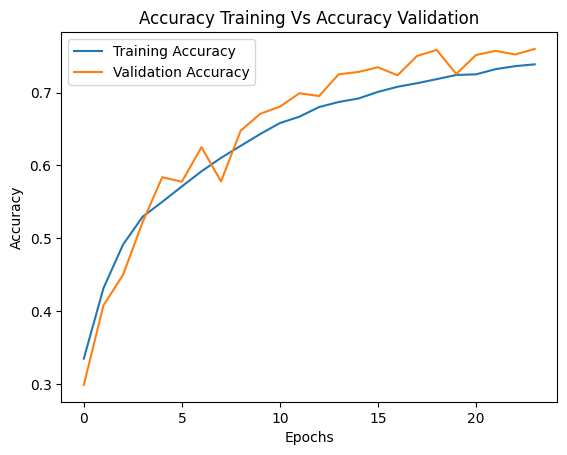

In [ ]:
#Plotting the accuracy:
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Training Vs Accuracy Validation")
plt.legend(loc="best")

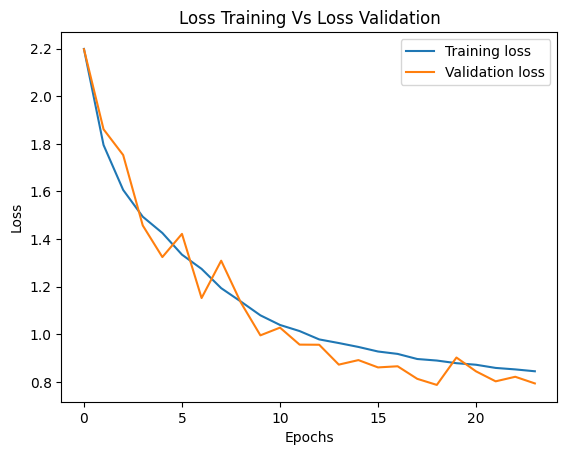

In [ ]:
#Plotting the loss:
plt.plot(history.history["loss"],label="Training loss")
plt.plot(history.history["val_loss"],label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Training Vs Loss Validation")
plt.legend(loc="best")

#  ¿Qué es ResNet?
[ResNet](https://medium.com/@siddheshb008/resnet-architecture-explained-47309ea9283d) (Redes Residuales) introduce conexiones residuales que permiten entrenar redes muy profundas evitando el problema de desvanecimiento del gradiente. Fue propuesta por Microsoft en 2015 y ganó el ILSVRC.
<img src="https://miro.medium.com/v2/resize:fit:850/1*C8jf92MeHZnxnbpMkz6jkQ.png" width="100%">

In [ ]:
x_train.shape

(45000, 32, 32, 3)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10
import numpy as np


# Cargamos los datos originales
(x_train_orig, y_train_orig), (x_test_orig, y_test_orig) = cifar10.load_data()

x_valid_orig = x_train_orig[:5000]
y_valid_orig = y_train_orig[:5000]
x_train_orig = x_train_orig[5000:]
y_train_orig = y_train_orig[5000:]

x_train_resnet = preprocess_input(x_train_orig.copy().astype('float32'))
x_valid_resnet = preprocess_input(x_valid_orig.copy().astype('float32'))
x_test_resnet = preprocess_input(x_test_orig.copy().astype('float32'))

y_train = to_categorical(y_train_orig, 10)
y_valid = to_categorical(y_valid_orig, 10)
y_test = to_categorical(y_test_orig, 10)


In [ ]:
base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False

model_resnet = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'), # Capa densa intermedia para análisis
    Dropout(0.5),                  # Dropout para regularizar esta nueva capa densa
    Dense(10, activation='softmax')
])

model_resnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

checkpoint_resnet = ModelCheckpoint("best_resnet_model.keras", save_best_only=True, monitor="val_accuracy", verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model_resnet.fit(
    x_train_resnet, y_train,
    epochs=40,
    validation_data=(x_valid_resnet, y_valid),
    callbacks=[checkpoint_resnet, early_stopping]
)

Epoch 1/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4964 - loss: 1.8200
Epoch 1: val_accuracy improved from -inf to 0.62860, saving model to best_resnet_model.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 95s 17ms/step - accuracy: 0.4964 - loss: 1.8198 - val_accuracy: 0.6286 - val_loss: 1.0501
Epoch 2/40
1405/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5989 - loss: 1.1605
Epoch 2: val_accuracy improved from 0.62860 to 0.64640, saving model to best_resnet_model.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.5989 - loss: 1.1606 - val_accuracy: 0.6464 - val_loss: 1.0080
Epoch 3/40
1402/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6216 - loss: 1.0950
Epoch 3: val_accuracy improved from 0.64640 to 0.65140, saving model to best_resnet_model.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.6216 - loss: 1.0950 - val_accuracy: 0.6514 - val_loss: 1.0123
Epoch 4/40
1405/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6384 - loss: 1.0412


In [ ]:
base_model.trainable = True

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


early_stopping_ft = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model_resnet.fit(
    x_train_resnet, y_train,
    epochs=40,
    validation_data=(x_valid_resnet, y_valid),
    callbacks=[checkpoint_resnet, early_stopping_ft]
)



Epoch 1/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3568 - loss: 2.1059
Epoch 1: val_accuracy did not improve from 0.68520
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 134s 54ms/step - accuracy: 0.3569 - loss: 2.1057 - val_accuracy: 0.5208 - val_loss: 1.3750
Epoch 2/40
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5249 - loss: 1.4070
Epoch 2: val_accuracy did not improve from 0.68520
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 91s 34ms/step - accuracy: 0.5249 - loss: 1.4070 - val_accuracy: 0.5992 - val_loss: 1.1551
Epoch 3/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5900 - loss: 1.1943
Epoch 3: val_accuracy did not improve from 0.68520
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 34ms/step - accuracy: 0.5900 - loss: 1.1942 - val_accuracy: 0.6472 - val_loss: 1.0179
Epoch 4/40
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6393 - loss: 1.0559
Epoch 4: val_accuracy did not improve from 0.68520
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 31ms/step - accuracy: 0.6393 - loss: 1.05

In [ ]:
# Evaluación
best_final_resnet = load_model("best_resnet_model.keras")
test_loss, test_accuracy = best_final_resnet.evaluate(x_test_resnet, y_test)
print(f"Precisión final en test (ResNet): {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7729 - loss: 0.8361
Precisión final en test (ResNet): 77.41%


In [ ]:
model_resnet.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,819,552 (281.60 MB)

 Trainable params: 24,588,810 (93.80 MB)

 Non-trainable params: 53,120 (207.50 KB)

 Optimizer params: 49,177,622 (187.60 MB)

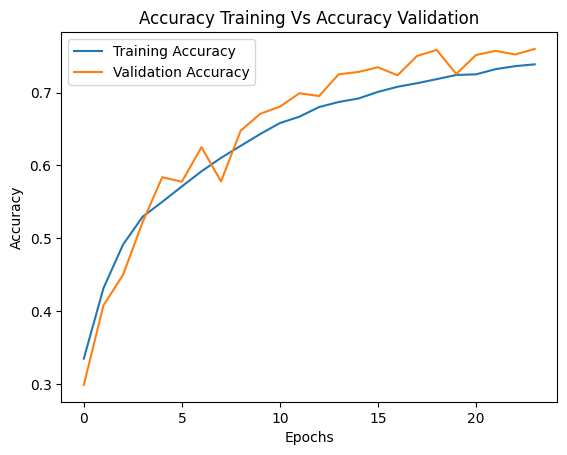

In [ ]:
#Plotting the accuracy:
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Training Vs Accuracy Validation")
plt.legend(loc="best")

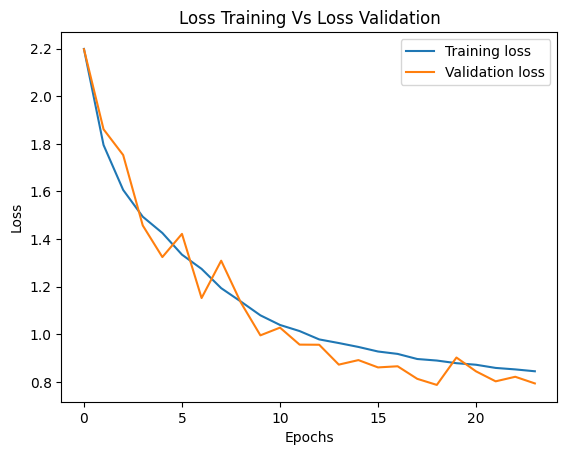

In [ ]:
#Plotting the loss:
plt.plot(history.history["loss"],label="Training loss")
plt.plot(history.history["val_loss"],label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Training Vs Loss Validation")
plt.legend(loc="best")

# ¿Qué es EfficientNet?
EfficientNet escala eficientemente la profundidad, ancho y resolución de la red mediante un método compuesto, [ver](https://medium.com/data-science/complete-architectural-details-of-all-efficientnet-models-5fd5b736142). Ofrece alta precisión con menos parámetros.
<img src="https://miro.medium.com/v2/resize:fit:2000/format:webp/1*rnhgFRXetwD8PvxhZIpwIA.png" width="100%">

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np


x_train_eff = preprocess_input(x_train_orig.copy().astype('float32'))
x_valid_eff = preprocess_input(x_valid_orig.copy().astype('float32'))
x_test_eff = preprocess_input(x_test_orig.copy().astype('float32'))

# Usamos EfficientNetB0 como base
base_model_eff = tf.keras.applications.EfficientNetB0(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model_eff.trainable = False

model_eff = Sequential([
    base_model_eff,
    GlobalAveragePooling2D(),
    Dense(10, activation='softmax')
])

model_eff.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

checkpoint_eff = ModelCheckpoint("best_efficientnet_model.keras", save_best_only=True, monitor="val_accuracy", verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model_eff.fit(
    x_train_eff, y_train,
    epochs=30,
    validation_data=(x_valid_eff, y_valid),
    callbacks=[checkpoint_eff, early_stopping]
)




16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3945 - loss: 1.7260
Epoch 1: val_accuracy improved from -inf to 0.52940, saving model to best_efficientnet_model.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 53s 23ms/step - accuracy: 0.3945 - loss: 1.7259 - val_accuracy: 0.5294 - val_loss: 1.3542
Epoch 2/30
1402/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5249 - loss: 1.3545
Epoch 2: val_accuracy improved from 0.52940 to 0.55040, saving model to best_efficientnet_model.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5250 - loss: 1.3544 - val_accuracy: 0.5504 - val_loss: 1.2931
Epoch 3/30
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5504 - loss: 1.2860
Epoch 3: val_accuracy improved from 0.55040 to 0.55520, saving model to best_efficientnet_model.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.5504 - loss: 1.2860 - val_accuracy: 0.5552 - val_loss: 1.2679
Epoch 4/30
1407/1407

In [ ]:
base_model_eff.trainable = True

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping_ft = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model_eff.fit(
    x_train_eff, y_train,
    epochs=30,
    validation_data=(x_valid_eff, y_valid),
    callbacks=[checkpoint_eff, early_stopping_ft]
)




Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.0868 - loss: 12.7493
Epoch 1: val_accuracy did not improve from 0.62000
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 144s 49ms/step - accuracy: 0.0868 - loss: 12.7481 - val_accuracy: 0.1808 - val_loss: 8.7036
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2021 - loss: 7.9319
Epoch 2: val_accuracy did not improve from 0.62000
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 71s 21ms/step - accuracy: 0.2021 - loss: 7.9315 - val_accuracy: 0.2598 - val_loss: 6.7422
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2785 - loss: 6.1171
Epoch 3: val_accuracy did not improve from 0.62000
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 18ms/step - accuracy: 0.2785 - loss: 6.1169 - val_accuracy: 0.3126 - val_loss: 5.5200
Epoch 4/30
1404/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3292 - loss: 5.0734
Epoch 4: val_accuracy did not improve from 0.62000
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 19ms/step - accuracy: 0.3292 - loss: 5.

In [ ]:
#Evaluación
best_final_eff = load_model("best_efficientnet_model.keras")
test_loss, test_accuracy = best_final_eff.evaluate(x_test_eff, y_test)
print(f"Precisión final en test (EfficientNet): {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.7529 - loss: 0.7195
Precisión Final en Test (EfficientNet): 75.41%


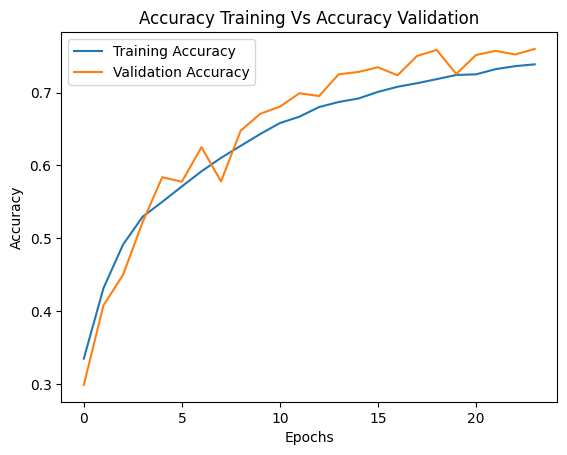

In [ ]:
#Plotting the accuracy:
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Training Vs Accuracy Validation")
plt.legend(loc="best")

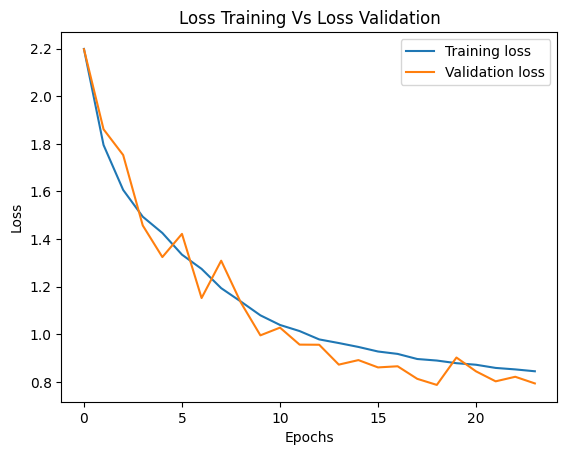

In [ ]:
#Plotting the loss:
plt.plot(history.history["loss"],label="Training loss")
plt.plot(history.history["val_loss"],label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Training Vs Loss Validation")
plt.legend(loc="best")

#¿Qué es VGG?
[VGG](https://medium.com/@siddheshb008/vgg-net-architecture-explained-71179310050f)
 es una arquitectura simple compuesta por bloques de convoluciones 3x3 con capas de pooling intercaladas. Es profunda pero fácil de entender.

<img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/1*B_ZaaaBg2njhp8SThjCufA.png" width="100%">

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np

x_train_vgg = preprocess_input(x_train_orig.copy().astype('float32'))
x_valid_vgg = preprocess_input(x_valid_orig.copy().astype('float32'))
x_test_vgg = preprocess_input(x_test_orig.copy().astype('float32'))

base_model_vgg = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model_vgg.trainable = False

model_vgg = Sequential([
    base_model_vgg,
    GlobalAveragePooling2D(),
    Dense(10, activation='softmax')
])


model_vgg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

checkpoint_vgg = ModelCheckpoint("best_vgg_model.keras", save_best_only=True, monitor="val_accuracy", verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model_vgg.fit(
    x_train_vgg, y_train,
    epochs=30,
    validation_data=(x_valid_vgg, y_valid),
    callbacks=[checkpoint_vgg, early_stopping]
)




58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4385 - loss: 6.7870
Epoch 1: val_accuracy improved from -inf to 0.58120, saving model to best_vgg_model.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.4385 - loss: 6.7851 - val_accuracy: 0.5812 - val_loss: 2.1675
Epoch 2/30
1405/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5974 - loss: 1.8366
Epoch 2: val_accuracy improved from 0.58120 to 0.60540, saving model to best_vgg_model.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.5974 - loss: 1.8365 - val_accuracy: 0.6054 - val_loss: 1.6795
Epoch 3/30
1402/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6086 - loss: 1.5426
Epoch 3: val_accuracy did not improve from 0.60540
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.6086 - loss: 1.5427 - val_accuracy: 0.5900 - val_loss: 1.5940
Epoch 4/30
1405/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6068 - loss: 1.5168


In [ ]:
base_model_vgg.trainable = True

model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping_ft = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model_vgg.fit(
    x_train_vgg, y_train,
    epochs=30,
    validation_data=(x_valid_vgg, y_valid),
    callbacks=[checkpoint_vgg, early_stopping_ft]
)


Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6926 - loss: 0.9153
Epoch 1: val_accuracy improved from 0.60760 to 0.78920, saving model to best_vgg_model.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 79s 49ms/step - accuracy: 0.6927 - loss: 0.9152 - val_accuracy: 0.7892 - val_loss: 0.6287
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8272 - loss: 0.5009
Epoch 2: val_accuracy improved from 0.78920 to 0.81660, saving model to best_vgg_model.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 50ms/step - accuracy: 0.8272 - loss: 0.5009 - val_accuracy: 0.8166 - val_loss: 0.5465
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8905 - loss: 0.3214
Epoch 3: val_accuracy improved from 0.81660 to 0.82500, saving model to best_vgg_model.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 100s 63ms/step - accuracy: 0.8905 - loss: 0.3214 - val_accuracy: 0.8250 - val_loss: 0.5326
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9255 - loss: 0.2151
E

In [ ]:
#Evaluación
best_final_vgg = load_model("best_vgg_model.keras")
test_loss, test_accuracy = best_final_vgg.evaluate(x_test_vgg, y_test)
print(f"Precisión Final en Test (VGG16): {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8238 - loss: 0.7748
Precisión Final en Test (VGG16): 82.53%


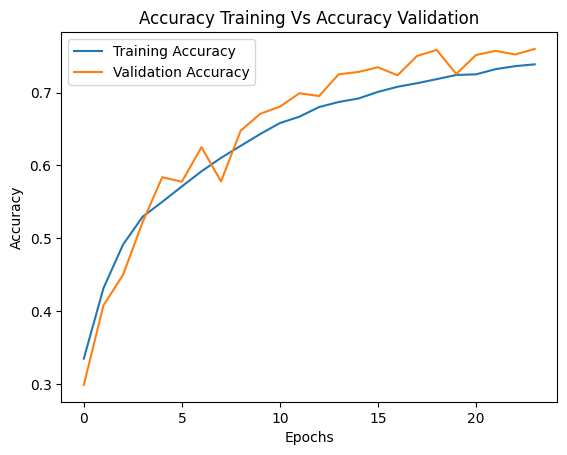

In [ ]:
#Plotting the accuracy:
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Training Vs Accuracy Validation")
plt.legend(loc="best")

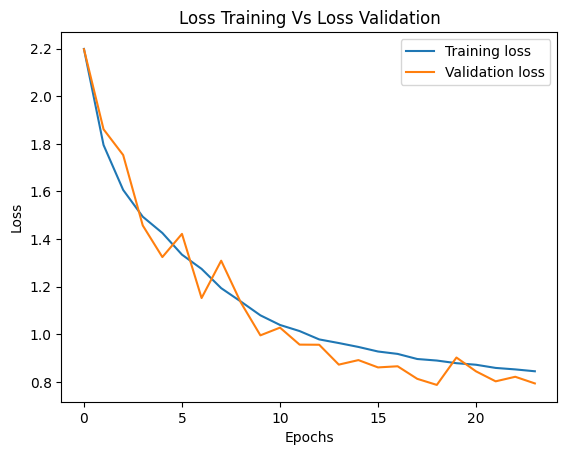

In [ ]:
#Plotting the loss:
plt.plot(history.history["loss"],label="Training loss")
plt.plot(history.history["val_loss"],label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Training Vs Loss Validation")
plt.legend(loc="best")

# ¿Qué es MobileNet?
[MobileNet](https://medium.com/@pandrii000/mobilenet-architectures-17fe7406d794) está optimizado para dispositivos móviles. Usa convoluciones separables en profundidad (depthwise separable convolutions) para reducir el costo computacional.
<img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/1*OghXrmqLYrPExgNF85BZCg.png" width="100%">



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np


x_train_mob = preprocess_input(x_train_orig.copy().astype('float32'))
x_valid_mob = preprocess_input(x_valid_orig.copy().astype('float32'))
x_test_mob = preprocess_input(x_test_orig.copy().astype('float32'))


base_model_mob = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model_mob.trainable = False

model_mob = Sequential([
    base_model_mob,
    GlobalAveragePooling2D(),
    Dense(10, activation='softmax')
])


model_mob.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

checkpoint_mob = ModelCheckpoint("best_mobilenet_model.keras", save_best_only=True, monitor="val_accuracy", verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model_mob.fit(
    x_train_mob, y_train,
    epochs=30,
    validation_data=(x_valid_mob, y_valid),
    callbacks=[checkpoint_mob, early_stopping]
)



/tmp/ipython-input-17-1834905441.py:14: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_mob = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2315 - loss: 2.1667
Epoch 1: val_accuracy improved from -inf to 0.27660, saving model to best_mobilenet_model.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.2315 - loss: 2.1667 - val_accuracy: 0.2766 - val_loss: 2.0212
Epoch 2/30
1404/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2810 - loss: 2.0025
Epoch 2: val_accuracy did not improve from 0.27660
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.2810 - loss: 2.0024 - val_accuracy: 0.2766 - val_loss: 1.9870
Epoch 3/30
1403/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2869 - loss: 1.9695
Epoch 3: val_accuracy improved from 0.27660 to 0.27920, saving model to best_mobilenet_model.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.2869 - loss: 1.9695 - val_accuracy: 0.2792 - val_loss: 1.9745
Epoch 4/30
1403/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2858 - loss: 1.9549
Epoch 4: val_accuracy improved from 0.279

In [ ]:

base_model_mob.trainable = True

model_mob.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping_ft = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

model_mob.fit(
    x_train_mob, y_train,
    epochs=50,
    validation_data=(x_valid_mob, y_valid),
    callbacks=[checkpoint_mob, early_stopping_ft]
)


best_final_mob = load_model("best_mobilenet_model.keras")
test_loss, test_accuracy = best_final_mob.evaluate(x_test_mob, y_test)
print(f"Precisión final en test (MobileNetV2): {test_accuracy * 100:.2f}%")

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1548 - loss: 11.0602
Epoch 1: val_accuracy did not improve from 0.28820
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 86s 29ms/step - accuracy: 0.1548 - loss: 11.0583 - val_accuracy: 0.1766 - val_loss: 3.6211
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2400 - loss: 4.1611
Epoch 2: val_accuracy did not improve from 0.28820
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.2400 - loss: 4.1608 - val_accuracy: 0.2042 - val_loss: 2.4676
Epoch 3/50
1405/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2678 - loss: 2.6789
Epoch 3: val_accuracy did not improve from 0.28820
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.2679 - loss: 2.6785 - val_accuracy: 0.2554 - val_loss: 2.2348
Epoch 4/50
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3028 - loss: 2.1462
Epoch 4: val_accuracy improved from 0.28820 to 0.32680, saving model to best_mobilenet_model.keras
1407/1407 ━━━━━━━━━━━━━━━━━

In [ ]:
#Plotting the accuracy:
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Training Vs Accuracy Validation")
plt.legend(loc="best")

NameError: name 'history' is not defined

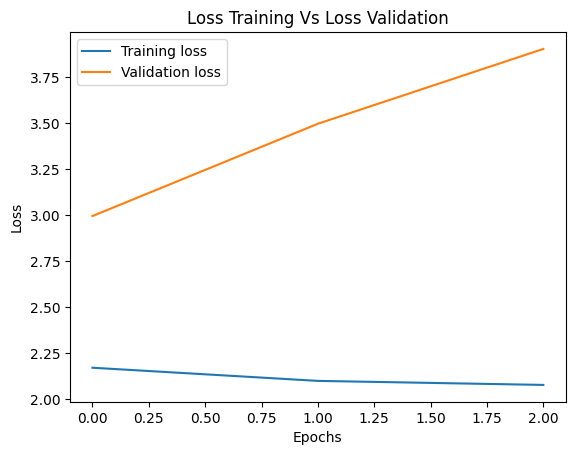

In [ ]:
#Plotting the loss:
plt.plot(history.history["loss"],label="Training loss")
plt.plot(history.history["val_loss"],label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Training Vs Loss Validation")
plt.legend(loc="best")

#Conclusión
El modelo VGG demostró una superioridad notable en la tarea de clasificación de imágenes del dataset CIFAR-10. A pesar de ser una arquitectura clásica, la aplicación de una estrategia de aprendizaje por transferencia en dos fases le permitió alcanzar una precisión final del 82.53%. Este rendimiento no solo valida la metodología empleada, sino que también posiciona a VGG por encima de arquitecturas más modernas como ResNet y EfficientNet en el marco de este experimento.

